# Modeling Longitudinal Learning Dynamics Using Markov Models
### A Python notebook for the VaSSTra method (Variables → States → Trajectories)

**Student:** Athar Hussain (F22BINFT1M01231) — BSIT Final Year Project
**Supervisor:** Dr. Mustafa Hameed — The Islamia University of Bahawalpur

This notebook is a **Python translation of the original R tutorial** (`ch11-vasstra.qmd`,
*"A tutorial with R for The VaSSTra Method"* by López-Pernas & Saqr). Every R step has been
reimplemented with the Python scientific stack (pandas, NumPy, scikit-learn, Matplotlib, SciPy)
so the project contains **no R code**. It runs on the project's real data
(`data/raw/LongitudinalEngagement.csv`) and mirrors `backend/run_vasstra_pipeline.py`.

The VaSSTra method moves from **Va**riables → **S**tates → **Tra**jectories, and we add the
**Markov state-transition matrix** that gives the project its title.

## 1. Packages — R → Python mapping

| R (original tutorial) | Purpose | Python equivalent (used here) |
|---|---|---|
| `rio::import` | Read data | `pandas.read_csv` |
| `tidyverse` / `dplyr` | Data wrangling | `pandas` |
| `BBmisc::normalize` | Standardize variables | group-wise z-score in `pandas` |
| `tidyLPA` / `mclust` | Latent profiles / states | `sklearn.mixture.GaussianMixture` |
| `TraMineR` (`seqdef`, `seqdist`) | Sequence objects & distances | one-hot + `sklearn` metrics |
| `cluster::agnes` / `hclust` | Hierarchical clustering | `sklearn.cluster.AgglomerativeClustering`, `scipy` dendrogram |
| `seqtrate` | Transition rates | NumPy transition-count matrix (Markov) |
| `ggplot2` | Plots | `matplotlib` |

In [1]:
%matplotlib inline
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

# Reproducibility and method configuration (identical to backend/run_vasstra_pipeline.py)
RSEED = 2026
STATE_COUNT = 3
TRAJECTORY_COUNT = 3
STATE_NAMES = ["Disengaged", "Average", "Active"]
CLUSTER_COLUMNS = [
    "Freq_Course_View", "Freq_Forum_Consume", "Freq_Forum_Contribute", "Freq_Lecture_View",
    "Regularity_Course_View", "Session_Count", "Total_Duration", "Active_Days",
]
np.random.seed(RSEED)

def find_data():
    # Robust to running from the notebook folder or the project root.
    here = Path.cwd().resolve()
    for base in [here, *here.parents]:
        cand = base / "data" / "raw" / "LongitudinalEngagement.csv"
        if cand.exists():
            return cand
    raise FileNotFoundError("LongitudinalEngagement.csv not found under any parent of CWD")

DATA_PATH = find_data()
print("Using data:", DATA_PATH)

Using data: D:\final year report generation\VaSSTra_Method\data\raw\LongitudinalEngagement.csv


## 2. The dataset

The original R loads `LongitudinalEngagement.csv`. We load the same file. Each row is one
student (`UserID`) in one weekly time point (`Sequence`, 1–8) with behavioural indicators
and a `Final_Grade`.

In [2]:
df = pd.read_csv(DATA_PATH)
print("rows:", len(df), "| students:", df["UserID"].nunique(),
      "| time points:", sorted(df["Sequence"].unique()))
df.head()

rows: 1136 | students: 142 | time points: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


,UserID,CourseID,Sequence,Freq_Course_View,Freq_Forum_Consume,Freq_Forum_Contribute,Freq_Lecture_View,Regularity_Course_View,Regularity_Lecture_View,Regularity_Forum_Consume,Regularity_Forum_Contribute,Session_Count,Total_Duration,Active_Days,Final_Grade
0,D2C5F64E,C6107FC4,1,150,251,79,132,0.42,0.38,0.18,0.83,121,53330,12,50.04
1,D2C5F64E,4C3F37F0,2,98,84,17,108,0.26,0.49,0.11,0.03,53,14465,5,38.86
2,D2C5F64E,E54A52A3,3,254,354,34,284,0.29,0.56,0.14,0.07,159,64324,12,44.73
3,D2C5F64E,AB7EC624,4,332,825,185,256,0.63,0.84,0.53,0.53,287,122821,19,48.99
4,D2C5F64E,B0E95213,5,386,960,233,356,0.74,0.80,0.75,0.56,321,148792,23,47.84


## 3. From variables to states

### Standardize variables *within each course*
R: `group_by(CourseID) |> mutate_at(..., normalize(method = "standardize"))`.
We z-score each indicator within its `CourseID` (mean 0, sd 1), filling undefined values with 0.

In [3]:
def standardize_within_course(frame):
    out = frame.copy()
    for col in CLUSTER_COLUMNS:
        g = out.groupby("CourseID")[col]
        mean = g.transform("mean")
        std = g.transform("std").replace(0, np.nan)
        out[col] = ((out[col] - mean) / std).fillna(0.0)
    return out

std_df = standardize_within_course(df)
std_df[CLUSTER_COLUMNS].describe().round(2)

,Freq_Course_View,Freq_Forum_Consume,Freq_Forum_Contribute,Freq_Lecture_View,Regularity_Course_View,Session_Count,Total_Duration,Active_Days
count,1136.00,1136.00,1136.00,1136.00,1136.00,1136.00,1136.00,1136.00
mean,-0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,0.00
std,0.98,0.98,0.98,0.98,0.98,0.98,0.98,0.98
min,-2.79,-2.69,-2.79,-2.63,-3.69,-2.94,-2.64,-3.94
25%,-0.68,-0.66,-0.66,-0.70,-0.70,-0.69,-0.71,-0.64
50%,0.00,0.02,-0.01,0.00,0.01,0.03,0.00,0.00
75%,0.67,0.65,0.63,0.73,0.72,0.68,0.64,0.64
max,4.20,3.18,4.10,3.91,2.71,2.52,4.13,3.09


### Model selection: how many states?
R uses `tidyLPA::estimate_profiles` + `compare_solutions` (AIC/BIC). The Python equivalent of
latent-profile analysis is a **Gaussian mixture model**. We scan 1–10 components and compare
BIC / AIC — lower is better.

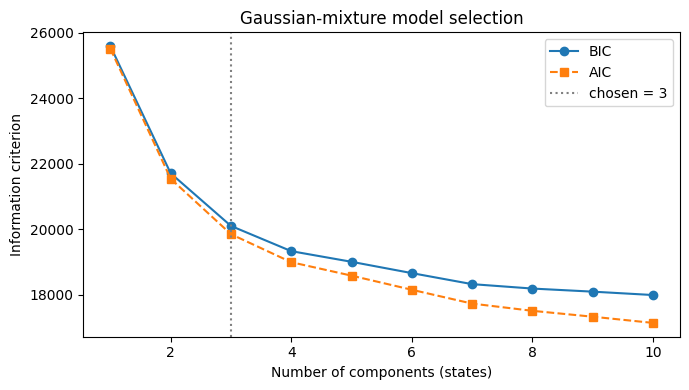

,components,BIC,AIC
0,1,25594.0,25513.4
1,2,21710.8,21544.6
2,3,20103.6,19851.8
3,4,19333.2,18995.9
4,5,19008.2,18585.2
5,6,18662.6,18154.0
6,7,18325.8,17731.6
7,8,18190.8,17511.0
8,9,18096.4,17331.0
9,10,17993.1,17142.2


In [4]:
features = std_df[CLUSTER_COLUMNS]
rows = []
for k in range(1, 11):
    gm = GaussianMixture(n_components=k, covariance_type="diag", random_state=RSEED, n_init=5)
    gm.fit(features)
    rows.append({"components": k, "BIC": gm.bic(features), "AIC": gm.aic(features)})
selection = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(selection["components"], selection["BIC"], "o-", label="BIC")
ax.plot(selection["components"], selection["AIC"], "s--", label="AIC")
ax.axvline(STATE_COUNT, color="grey", ls=":", label=f"chosen = {STATE_COUNT}")
ax.set_xlabel("Number of components (states)"); ax.set_ylabel("Information criterion")
ax.set_title("Gaussian-mixture model selection"); ax.legend(); fig.tight_layout()
plt.show()
selection.round(1)

### Fit the chosen 3-state model and label the states
We fit a 3-component mixture, then order the components by their average standardized level and
label them **Disengaged → Average → Active** (R: relabelling the LPA classes as engagement levels).

In [5]:
gmm = GaussianMixture(n_components=STATE_COUNT, covariance_type="diag",
                      random_state=RSEED, n_init=15).fit(features)
comp = gmm.predict(features)
order = np.argsort(gmm.means_.mean(axis=1))          # low -> high engagement
mapping = {c: STATE_NAMES[i] for i, c in enumerate(order)}

std_df["State"] = [mapping[c] for c in comp]
std_df["State"] = pd.Categorical(std_df["State"], categories=STATE_NAMES, ordered=True)
std_df["State"].value_counts().reindex(STATE_NAMES)

State
Disengaged    264
Average       493
Active        379
Name: count, dtype: int64

### Mean standardized profile of each state
R: `ggplot(aes(fill = name, y = value, x = State)) + geom_col(position = "dodge")`.

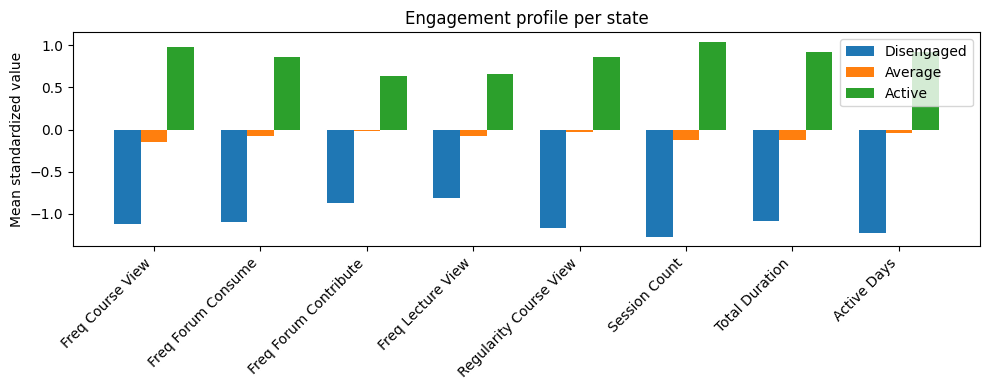

,Freq_Course_View,Freq_Forum_Consume,Freq_Forum_Contribute,Freq_Lecture_View,Regularity_Course_View,Session_Count,Total_Duration,Active_Days
State,,,,,,,,
Disengaged,-1.13,-1.09,-0.87,-0.81,-1.17,-1.27,-1.09,-1.23
Average,-0.15,-0.07,-0.02,-0.08,-0.03,-0.12,-0.12,-0.05
Active,0.98,0.86,0.63,0.66,0.86,1.04,0.92,0.92


In [6]:
profile = std_df.groupby("State", observed=True)[CLUSTER_COLUMNS].mean().reindex(STATE_NAMES)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(CLUSTER_COLUMNS)); w = 0.25
for i, state in enumerate(STATE_NAMES):
    ax.bar(x + (i - 1) * w, profile.loc[state].values, width=w, label=state)
ax.set_xticks(x); ax.set_xticklabels([c.replace("_", " ") for c in CLUSTER_COLUMNS], rotation=45, ha="right")
ax.set_ylabel("Mean standardized value"); ax.set_title("Engagement profile per state"); ax.legend()
fig.tight_layout(); plt.show()
profile.round(2)

## 4. From states to sequences
R: `pivot_wider(id_cols = UserID, names_from = Sequence, values_from = State)` then `seqdef`.
We pivot to one row per student with the ordered state sequence across the 8 time points.

In [7]:
seq_cols = [f"step_{i}" for i in range(1, 9)]
sequences = (std_df.sort_values(["UserID", "Sequence"])
             .pivot_table(index="UserID", columns="Sequence", values="State", aggfunc="first", observed=True))
sequences = sequences.reindex(columns=range(1, 9))
sequences.columns = seq_cols
sequences = sequences.astype(object).apply(lambda s: s.fillna("Average"))
sequences = sequences.reset_index()
sequences.head()

,UserID,step_1,step_2,step_3,step_4,step_5,step_6,step_7,step_8
0,00050F0E,Average,Disengaged,Average,Average,Average,Average,Average,Average
1,006DD50A,Average,Active,Average,Average,Average,Average,Disengaged,Average
2,05D0E111,Average,Disengaged,Average,Average,Average,Disengaged,Average,Average
3,0637AF03,Active,Active,Active,Active,Active,Active,Active,Active
4,065F7507,Disengaged,Disengaged,Average,Disengaged,Average,Average,Average,Disengaged


### State distribution across time (sequence-distribution plot)
R: `seqdplot`. Proportion of students in each state at each time point.

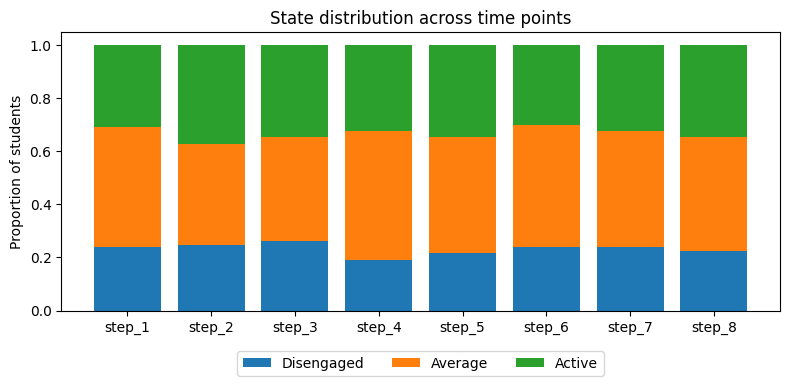

,Disengaged,Average,Active
step_1,0.24,0.45,0.31
step_2,0.25,0.38,0.37
step_3,0.26,0.39,0.35
step_4,0.19,0.49,0.32
step_5,0.22,0.44,0.35
step_6,0.24,0.46,0.30
step_7,0.24,0.44,0.32
step_8,0.23,0.43,0.35


In [8]:
dist = pd.DataFrame({c: sequences[c].value_counts(normalize=True) for c in seq_cols}).reindex(STATE_NAMES).T
fig, ax = plt.subplots(figsize=(8, 4))
bottom = np.zeros(len(seq_cols))
for state in STATE_NAMES:
    ax.bar(seq_cols, dist[state].values, bottom=bottom, label=state)
    bottom += dist[state].values
ax.set_ylabel("Proportion of students"); ax.set_title("State distribution across time points")
ax.legend(loc="upper center", ncol=3, bbox_to_anchor=(0.5, -0.12)); fig.tight_layout(); plt.show()
dist.round(2)

## 5. From sequences to trajectories
R: `seqdist` (LCS distance) + `hclust`/`agnes` (Ward) to group whole sequences into trajectories.
In Python we one-hot encode the per-step states and run **Ward agglomerative clustering** (same as
the backend pipeline). We pick the number of trajectories with the silhouette score.

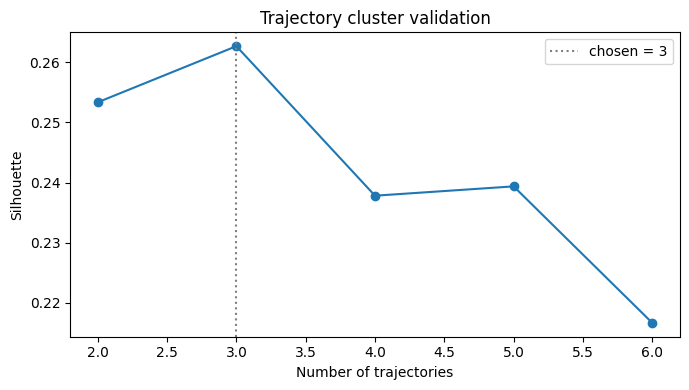

,clusters,silhouette
0,2,0.2534
1,3,0.2627
2,4,0.2378
3,5,0.2394
4,6,0.2166


In [9]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoded = encoder.fit_transform(sequences[seq_cols])

sil = []
for k in range(2, 7):
    labels = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(encoded)
    sil.append({"clusters": k, "silhouette": silhouette_score(encoded, labels)})
sil = pd.DataFrame(sil)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sil["clusters"], sil["silhouette"], "o-")
ax.axvline(TRAJECTORY_COUNT, color="grey", ls=":", label=f"chosen = {TRAJECTORY_COUNT}")
ax.set_xlabel("Number of trajectories"); ax.set_ylabel("Silhouette"); ax.legend()
ax.set_title("Trajectory cluster validation"); fig.tight_layout(); plt.show()
sil.round(4)

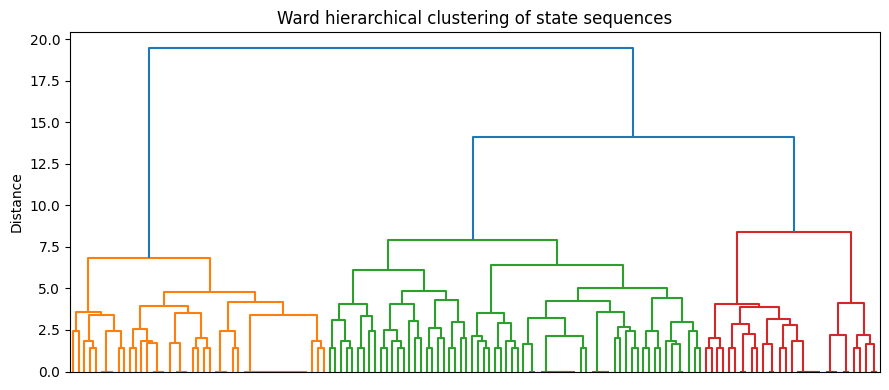

In [10]:
# Dendrogram (R: plot of the hclust/agnes tree)
Z = linkage(encoded, method="ward")
fig, ax = plt.subplots(figsize=(9, 4))
dendrogram(Z, no_labels=True, color_threshold=Z[-(TRAJECTORY_COUNT - 1), 2], ax=ax)
ax.set_title("Ward hierarchical clustering of state sequences"); ax.set_ylabel("Distance")
fig.tight_layout(); plt.show()

### Assign and name the trajectories
R relabels clusters as *Mostly active / Mostly average / Mostly disengaged* based on their state
composition. We use the same rule as the backend.

In [11]:
labels = AgglomerativeClustering(n_clusters=TRAJECTORY_COUNT, linkage="ward").fit_predict(encoded)
sequences["trajectory"] = labels + 1

long = sequences.melt(id_vars=["UserID", "trajectory"], value_vars=seq_cols, value_name="State")
shares = (long.groupby("trajectory")["State"].value_counts(normalize=True)
          .unstack().reindex(columns=STATE_NAMES).fillna(0.0))

active = shares["Active"].idxmax()
disengaged = shares.drop(index=active)["Disengaged"].idxmax()
average = [t for t in shares.index if t not in {active, disengaged}][0]
names = {active: "Mostly active", average: "Mostly average", disengaged: "Mostly disengaged"}
sequences["trajectory_label"] = sequences["trajectory"].map(names)

grades = df.groupby("UserID", as_index=False)["Final_Grade"].mean()
summary = (sequences.merge(grades, on="UserID", how="left")
           .groupby("trajectory_label")
           .agg(students=("UserID", "size"), mean_final_grade=("Final_Grade", "mean")).round(2))
summary

,students,mean_final_grade
trajectory_label,,
Mostly active,45,73.41
Mostly average,66,67.36
Mostly disengaged,31,62.31


### Sequence index plot grouped by trajectory
R: `seqIplot(clus_seq, group = trajectories)`. Each row is a student's colour-coded state sequence,
grouped by trajectory.

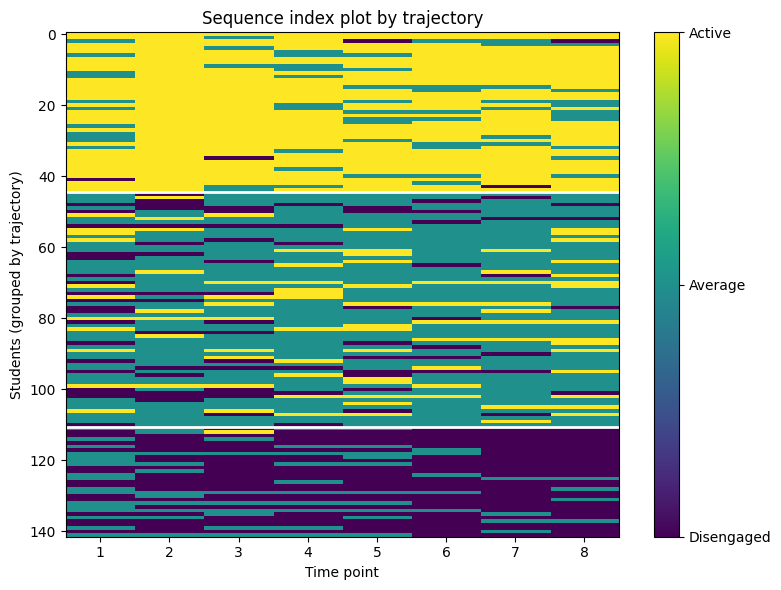

In [12]:
code_of = {s: i for i, s in enumerate(STATE_NAMES)}
ordered = sequences.sort_values(["trajectory_label", "UserID"])
mat = ordered[seq_cols].map(lambda s: code_of[s]).values

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(mat, aspect="auto", interpolation="nearest", cmap="viridis")
ax.set_xlabel("Time point"); ax.set_ylabel("Students (grouped by trajectory)")
ax.set_xticks(range(8)); ax.set_xticklabels(range(1, 9))
boundaries = ordered["trajectory_label"].values
ys = [i for i in range(1, len(boundaries)) if boundaries[i] != boundaries[i - 1]]
for y in ys:
    ax.axhline(y - 0.5, color="white", lw=2)
cbar = fig.colorbar(im, ax=ax, ticks=range(len(STATE_NAMES))); cbar.ax.set_yticklabels(STATE_NAMES)
ax.set_title("Sequence index plot by trajectory"); fig.tight_layout(); plt.show()

## 6. Markov state-transition matrices
This is the **Markov** core of the project title. R computes transition rates with `seqtrate`.
For a first-order Markov chain over the states *{Disengaged, Average, Active}*, the transition
matrix **P** holds `P[i, j] = Pr(state_{t+1} = j | state_t = i)`, estimated from every consecutive
step pair across all students.

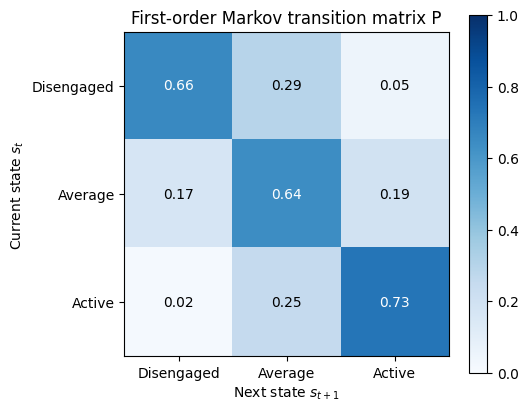

,Disengaged,Average,Active
Disengaged,0.659,0.293,0.047
Average,0.167,0.644,0.190
Active,0.015,0.252,0.733


In [13]:
def transition_matrix(seq_frame, cols, states):
    idx = {s: i for i, s in enumerate(states)}
    counts = np.zeros((len(states), len(states)))
    for seq in seq_frame[cols].itertuples(index=False):
        for a, b in zip(seq[:-1], seq[1:]):
            counts[idx[a], idx[b]] += 1
    probs = counts / counts.sum(axis=1, keepdims=True)
    return counts, probs

counts, P = transition_matrix(sequences, seq_cols, STATE_NAMES)
P_df = pd.DataFrame(P, index=STATE_NAMES, columns=STATE_NAMES)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(P, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(3)); ax.set_xticklabels(STATE_NAMES)
ax.set_yticks(range(3)); ax.set_yticklabels(STATE_NAMES)
ax.set_xlabel("Next state $s_{t+1}$"); ax.set_ylabel("Current state $s_t$")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{P[i, j]:.2f}", ha="center", va="center",
                color="white" if P[i, j] > 0.5 else "black")
ax.set_title("First-order Markov transition matrix P"); fig.colorbar(im, ax=ax); fig.tight_layout(); plt.show()
P_df.round(3)

### Transition matrices per trajectory
Each trajectory is governed by its own Markov dynamics — e.g. the *Mostly active* group should
have high self-persistence on **Active**, while *Mostly disengaged* persists on **Disengaged**.

In [14]:
for label in ["Mostly active", "Mostly average", "Mostly disengaged"]:
    sub = sequences[sequences["trajectory_label"] == label]
    if sub.empty:
        continue
    _, Pk = transition_matrix(sub, seq_cols, STATE_NAMES)
    print(f"\n=== {label}  (n={len(sub)}) ===")
    print(pd.DataFrame(Pk, index=STATE_NAMES, columns=STATE_NAMES).round(3))


=== Mostly active  (n=45) ===
            Disengaged  Average  Active
Disengaged       0.000    0.250   0.750
Average          0.020    0.255   0.725
Active           0.012    0.138   0.850

=== Mostly average  (n=66) ===
            Disengaged  Average  Active
Disengaged       0.286    0.610   0.104
Average          0.123    0.737   0.139
Active           0.014    0.681   0.304

=== Mostly disengaged  (n=31) ===
            Disengaged  Average  Active
Disengaged       0.868    0.132   0.000
Average          0.492    0.492   0.015
Active           1.000    0.000   0.000


## Summary

- **Variables → States:** within-course standardized indicators were grouped into 3 latent
  engagement states (Disengaged / Average / Active) with a Gaussian mixture model.
- **States → Trajectories:** per-student state sequences were clustered (Ward) into 3 learner
  trajectories (Mostly active / average / disengaged).
- **Markov modeling:** first-order transition matrices summarise how students move between states,
  overall and within each trajectory.

This Python notebook fully replaces the original R Quarto tutorial; the project now contains no R
code. The same logic powers `backend/run_vasstra_pipeline.py`, whose artifacts drive the web
dashboard.